# Task1 assignment data

### Theory Discussion

**PyTorch**

PyTorch is a popular open-source deep learning library developed by Meta. It makes it easier to build, train, and evaluate machine learning models using tensors and automatic differentiation. One of its biggest advantages is its flexible and intuitive design, which allows developers and researchers to experiment with models efficiently.

**Regression**

Regression is a supervised machine learning approach used to understand and predict numerical values. The main objective is to learn the relationship between input features and a target variable. Once the relationship is learned from historical data, the model can estimate outputs for unseen inputs.

**Why PyTorch for Regression?**

PyTorch provides built-in tools for creating custom models, defining loss functions, and optimizing model parameters. These features make it suitable for implementing regression algorithms and analyzing model performance through training and testing processes.


## TASK 1: {DATASET = assignment-data.csv}

# 1. Data Preparation

In [207]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [208]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


### Train-Test Split

In [209]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Data Visualization Function

In [210]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

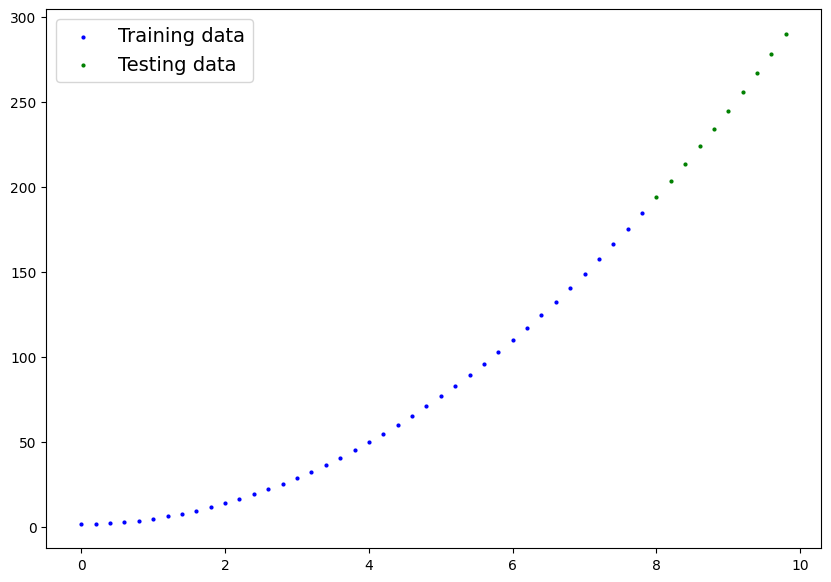

In [211]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## Algorithm Selection

We define a custom model:

y=ax2+bx+c

### Discussion These are learnable parameters which are initialized randomly.

They are updated during training using gradient descent.

In [212]:
# Create a Quadratic Regression model class
class QuadraticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.a = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.b = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.c = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.a * x**2 + self.b * x + self.c

In [213]:
model_0 = QuadraticRegressionModel()

In [214]:
print(model_0.a.dtype)
print(model_0.b.dtype)
print(model_0.c.dtype)

torch.float32
torch.float32
torch.float32


In [215]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413]])

### Discussion

Here, predictions are made without gradient descent. It is used for evaluation only,

### Observation

Initial predictions are untrained and do not align well with the actual data distribution.

In [216]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[22.8131],
        [23.9298],
        [25.0733],
        [26.2438],
        [27.4413],
        [28.6657],
        [29.9170],
        [31.1952],
        [32.5004],
        [33.8325]])


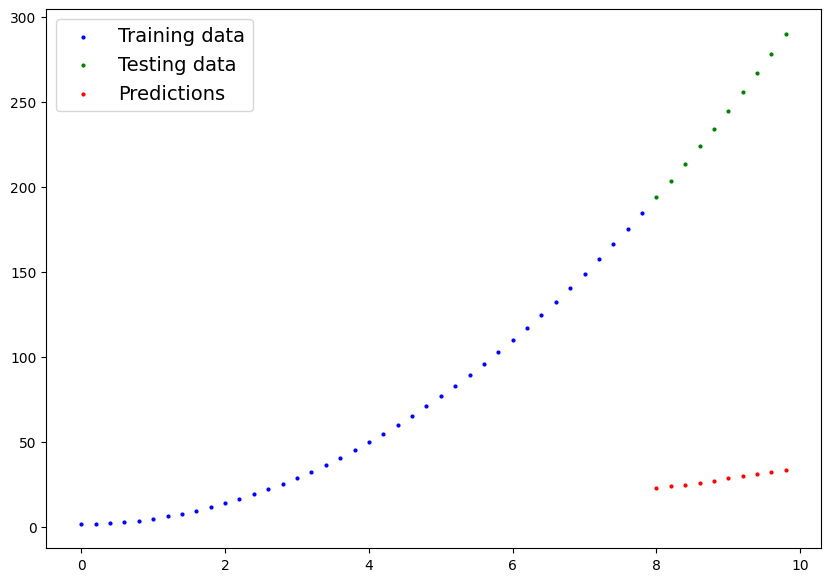

In [217]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [218]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### Discussion

Loss Function (MAE) measures error.

And,
SGD optimizer updates parameters to reduce error

In [219]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 500

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 55.967559814453125 | MAE Test Loss: 195.76417541503906 
Epoch: 10 | MAE Train Loss: 12.157402038574219 | MAE Test Loss: 28.818008422851562 
Epoch: 20 | MAE Train Loss: 2.427116870880127 | MAE Test Loss: 8.087414741516113 
Epoch: 30 | MAE Train Loss: 1.5925449132919312 | MAE Test Loss: 11.084966659545898 
Epoch: 40 | MAE Train Loss: 0.9689820408821106 | MAE Test Loss: 13.302360534667969 
Epoch: 50 | MAE Train Loss: 0.45725950598716736 | MAE Test Loss: 15.107688903808594 
Epoch: 60 | MAE Train Loss: 2.150113582611084 | MAE Test Loss: 8.50035285949707 
Epoch: 70 | MAE Train Loss: 1.5265477895736694 | MAE Test Loss: 10.717729568481445 
Epoch: 80 | MAE Train Loss: 1.0148272514343262 | MAE Test Loss: 12.52308177947998 
Epoch: 90 | MAE Train Loss: 0.6227549910545349 | MAE Test Loss: 13.890657424926758 
Epoch: 100 | MAE Train Loss: 1.0679795742034912 | MAE Test Loss: 12.078683853149414 
Epoch: 110 | MAE Train Loss: 0.7058199644088745 | MAE Test Loss: 13.3368434906005

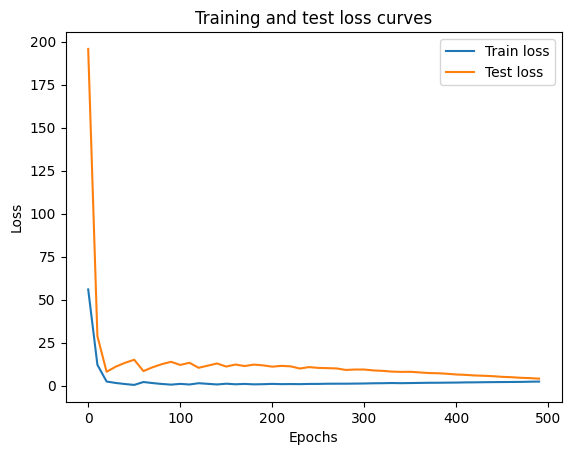

In [220]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### Discussion

The curves shows training vs testing error which help to verify machine learning.

### Observation

The decreasing curve shows that the model is learning.


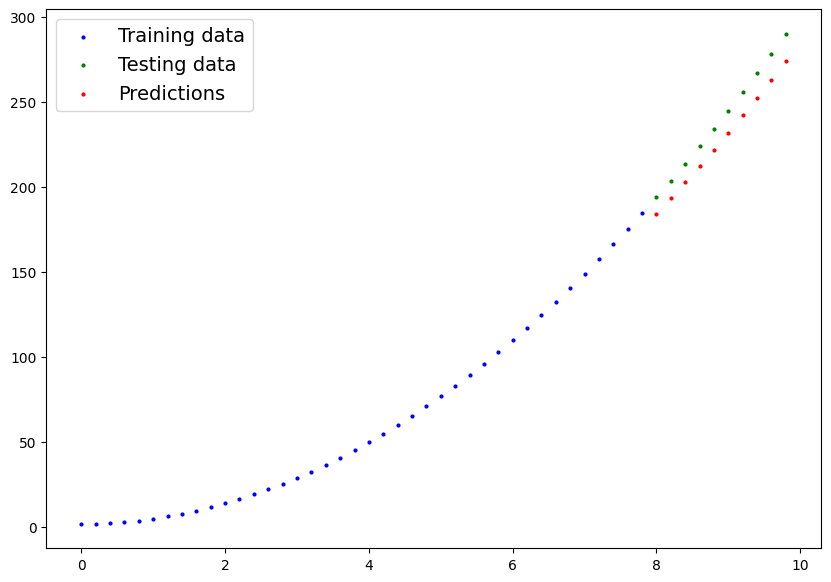

In [221]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

The Red points (predictions) align closely with actual data Indicates successful learning of quadratic relationship